In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Lab 12 - Permutation - Example Code (one continuous, one discrete (binary) variable)

### 1. Data Exploration

In [2]:
#load dataset
tbl_all = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-Fall2022/main/data/baby.csv')
tbl_all

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [3]:
#select only relevant columns
tbl = tbl_all.select('Maternal Smoker', 'Birth Weight')
tbl

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [6]:
#summary - count of each group
tbl.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


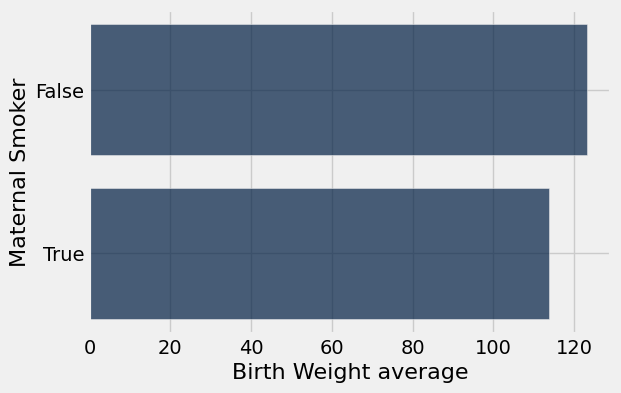

In [7]:
#summary - mean value of each group
tbl.group('Maternal Smoker', np.average).barh('Maternal Smoker')

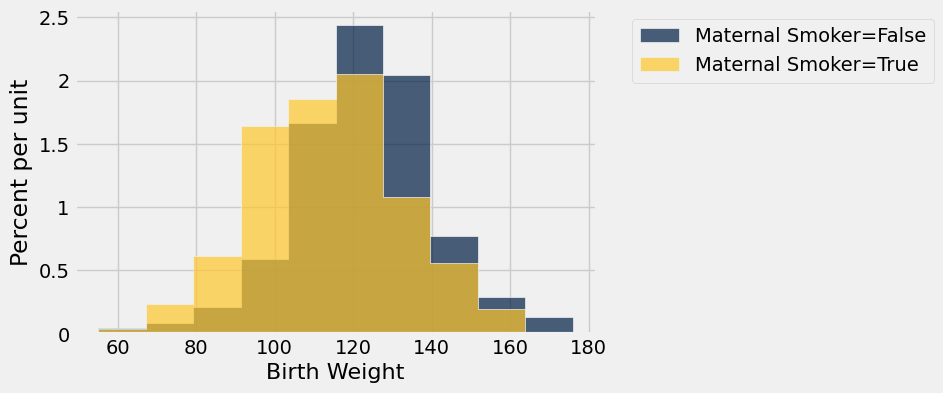

In [8]:
#summary - overlaid histogram
tbl.hist('Birth Weight', group='Maternal Smoker')

### 2. Permuation Test

In [9]:
#step1: determine test statistics
means_table = tbl.group('Maternal Smoker', np.average) # update
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [10]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [12]:
#function to calcuate difference of means
def difference_of_means(table, var1, var2):
    """
    table: name of table,
    var1: column label of numerical variable,
    var2: column label of group-label variable, a discrete variable
    Returns: Difference of means of the two groups"""
    #table with the two relevant columns
    reduced = table.select(var1, var2)
    # table containing group means
    means_table = reduced.group(var2, np.average)
    # array of group means
    means = means_table.column(1)
    return means.item(1) - means.item(0)

In [13]:
#test function above
difference_of_means(tbl, 'Birth Weight', 'Maternal Smoker') # update

-9.266142572024918

In [15]:
#step 2: run simulation
#2a function to run one iteration of simulation
def one_simulated_difference(table, var1, var2):
    """
    table: name of table
    var1: column label of numerical variable,
    var2: column label of group-label variable, a discrete avariable
    Returns: Difference of means of the two groups after shuffling labels"""
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled Label', shuffled_labels)
    return difference_of_means(shuffled_table, var1, 'Shuffled Label')

In [47]:
#test the function above
one_simulated_difference(tbl, 'Birth Weight', 'Maternal Smoker') # update

0.8002407178877888

In [48]:
#2b: function to run multiple iterations of simulation
differences = make_array()
for i in np.arange(100):
    new_difference = one_simulated_difference(tbl, 'Birth Weight', 'Maternal Smoker') # update
    differences = np.append(differences, new_difference)
differences

array([ 2.27406798, -0.10480369,  1.05780276, -0.25862547, -0.1405762 ,
       -0.58773253, -1.29960541, -0.55553727, -0.39813825, -0.89179883,
        2.34561299,  0.92544449, -0.27293447,  0.72869571, -1.03488886,
       -0.46252876, -1.18513339,  1.74105764, -0.4017155 ,  1.93422917,
       -1.02057986, -0.05114493,  1.11503877, -0.04399043,  1.30463306,
        1.21877904,  1.03633926, -0.45537426,  1.23308804, -1.23521489,
        0.77162271, -2.3727806 ,  0.55698767, -0.6914728 , -0.86318083,
       -0.53407377, -1.07781587,  0.29942563,  1.45130033, -0.84887183,
        1.71601688,  0.02755458, -0.9669211 , -0.15130795,  0.81812697,
       -1.32464616,  0.53910142,  1.19731554, -0.79163582, -1.88269726,
       -0.25504822,  2.402849  ,  0.62853269,  1.04707101,  0.96479425,
       -0.37667474, -0.64139129, -0.48756951,  0.17064461, -0.10122644,
       -1.09927937,  0.28869388,  0.45682466,  0.43536115,  1.63731737,
        0.89324923,  0.76446821,  0.09194509, -0.94545759,  1.25

Observed Difference: -9.266142572024918
p-value= 0.0


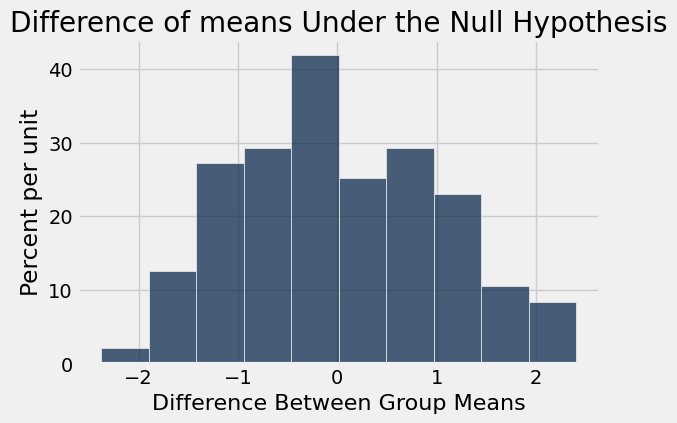

In [49]:
# step 3: visualize and interprete results
Table().with_column('Difference Between Group Means', differences).hist()
print('Observed Difference:', observed_difference)
print('p-value=',np.mean(differences<observed_difference))
plots.title('Difference of means Under the Null Hypothesis');